# Assignment 2 – Redesign a Notable Information Graphic  
## **[John Snow's Cholera Map]**

**Cholera broke out in London's Soho district in 1854 and killed hundreds.**  
**Dr. John Snow, a pioneering physician, mapped the locations of cholera deaths and water pumps and demonstrated a clear pattern of death around the Broad Street pump.**  
**His studies led to the removal of the pump handle, ending the epidemic.**  
**This was a turning point in public health, demonstrating that cholera was transmitted by water and laid the foundation for modern epidemiology.**

**This assignment is a redesigned version of John Snow’s 1854 cholera outbreak map, built using three CSV files: deaths, pumps, and outbreak dates.**  
**By combining these datasets with modern visualization tools like Plotly, the project transforms Snow’s original hand-drawn map into an interactive, data-driven experience.**


**This code then develops an animated globe visualization that narrates a geographical story. In this animation, the globe starts with a global view of the Earth, then zooms in to the United Kingdom, and eventually to London, where the outbreak took place. This shows the initial stage of the outbreak of cholera in London. This step will help the audience understand the geographical context of the epidemic. Next, this code will create an interactive map showing where the deaths due to cholera took place in London. The map will have markers representing the locations where the deaths were recorded. The size and color of the markers will vary according to the number of deaths in the initial stage. In addition to this, the map will also include blue-colored markers to denote the water pump locations. These water pumps were the main source of water for drinking.**


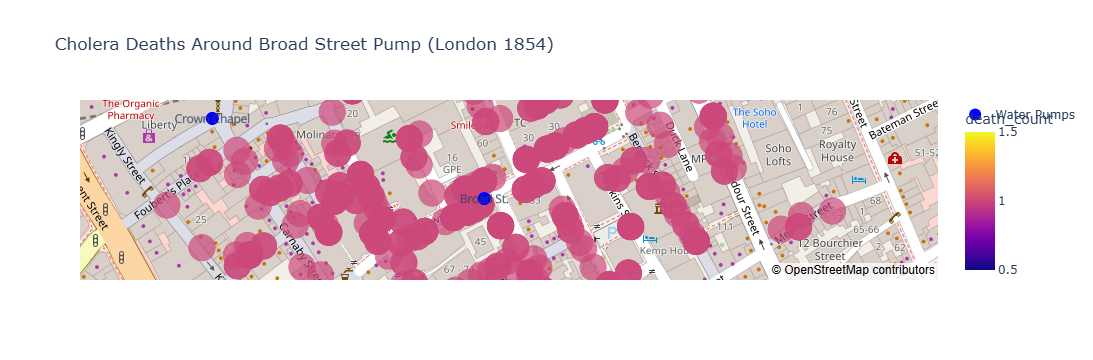

In [38]:
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px

# Load datasets
death_count = pd.read_csv(r"C:\Users\Sai Lalit\Downloads\death_count_list.csv")
pumps = pd.read_csv(r"C:\Users\Sai Lalit\Downloads\pump_names_list.csv")

# Coordinates
london_lat = 51.5135
london_lon = -0.1365

# Frames for animation
frames = [
    # Frame 1 – Globe
    go.Frame(
        name="Globe",
        layout=dict(
            geo=dict(
                projection_type="orthographic",
                center=dict(lat=20, lon=0),
                projection_rotation=dict(lon=0)
            )
        )
    ),

    # Frame 2 – Focus on UK
    go.Frame(
        name="UK",
        layout=dict(
            geo=dict(
                projection_type="orthographic",
                center=dict(lat=54, lon=-2),
                projection_rotation=dict(lon=-2)
            )
        )
    ),

    # Frame 3 – London zoom
    go.Frame(
        name="London",
        layout=dict(
            geo=dict(
                projection_type="orthographic",
                center=dict(lat=london_lat, lon=london_lon),
                projection_rotation=dict(lon=london_lon)
            )
        )
    )
]

# globe figure
fig = go.Figure(
    data=[
        go.Scattergeo(
            lon=[london_lon],
            lat=[london_lat],
            text=["London"],
            mode="markers+text",
            marker=dict(size=8, color="red")
        )
    ],
    frames=frames
)

fig.update_layout(
    title="Global Focus to London – 1854 Cholera Outbreak",
    geo=dict(
        projection_type="orthographic",
        showland=True,
        landcolor="lightgray",
        showocean=True,
        oceancolor="lightblue"
    ),
    updatemenus=[
        dict(type="buttons",
            buttons=[
                dict(label="Start Story",
                    method="animate",
                    args=[None])])]
)

fig = px.scatter_map(
    death_count,
    lat="latitude",
    lon="longitude",
    size="death_count",
    color="death_count",
    zoom=16,
    map_style="open-street-map",
    title="Cholera Deaths Around Broad Street Pump (London 1854)"
)

fig.update_traces(
    hovertemplate="Deaths: %{marker.size}<extra></extra>"
)

fig.add_scattermap(
    lat=pumps["latitude"],
    lon=pumps["longitude"],
    mode="markers+text",
    marker=dict(size=14, color="blue"),
    text=pumps["pump_name"],
    name="Water Pumps"
)

fig.show()


In [20]:
import pandas as pd
from pathlib import Path

path_file1 = Path(r"C:\Users\Sai Lalit\Downloads\death_count_list.csv")
print("file exists:",path_file1.exists())

path_file2 = Path(r"C:\Users\Sai Lalit\Downloads\pump_names_list.csv")
print("file exists:", path_file2.exists())

path_file3 = Path(r"C:\Users\Sai Lalit\Downloads\snow_dates.csv")
print("file exists:", path_file3.exists())





file exists: True
file exists: True
file exists: True


In [21]:
df = pd.read_csv(r"C:\Users\Sai Lalit\Downloads\death_count_list.csv")
df.head()

,death_count,latitude,longitude
0,1,51.513418,-0.137930
1,1,51.513418,-0.137930
2,1,51.513418,-0.137930
3,1,51.513361,-0.137883
4,1,51.513361,-0.137883


In [12]:
df2 = pd.read_csv(r"C:\Users\Sai Lalit\Downloads\pump_names_list.csv")
df2.head()

,pump_name,latitude,longitude
0,Broad St.,51.513341,-0.136668
1,Crown Chapel,51.513876,-0.139586
2,Gt Marlborough,51.514906,-0.139671
3,Dean St.,51.512354,-0.131630
4,So Soho,51.512139,-0.133594


In [13]:
df3 = pd.read_csv(r"C:\Users\Sai Lalit\Downloads\snow_dates.csv")
df3.head()

,order,date,attacks,deaths
0,1,1854-08-19,1,1
1,2,1854-08-20,1,0
2,3,1854-08-21,1,2
3,4,1854-08-22,0,0
4,5,1854-08-23,1,0



**The below redesigned map shows that the John Snow's 1854 cholera outbreak using  the modern tools. To put it in more detail, this is the density map which shows the total death count in a map style carto-positron. Moreover, their is a hover functionality on map which shows latitude and longitude as well as the death count on the basis of the csv file. Eventually, this is the transformed version of Snow's map with the aid of plotly express.**

C:\Users\Sai Lalit\AppData\Local\Temp\ipykernel_8932\1348297684.py:10: DeprecationWarning:

*density_mapbox* is deprecated! Use *density_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



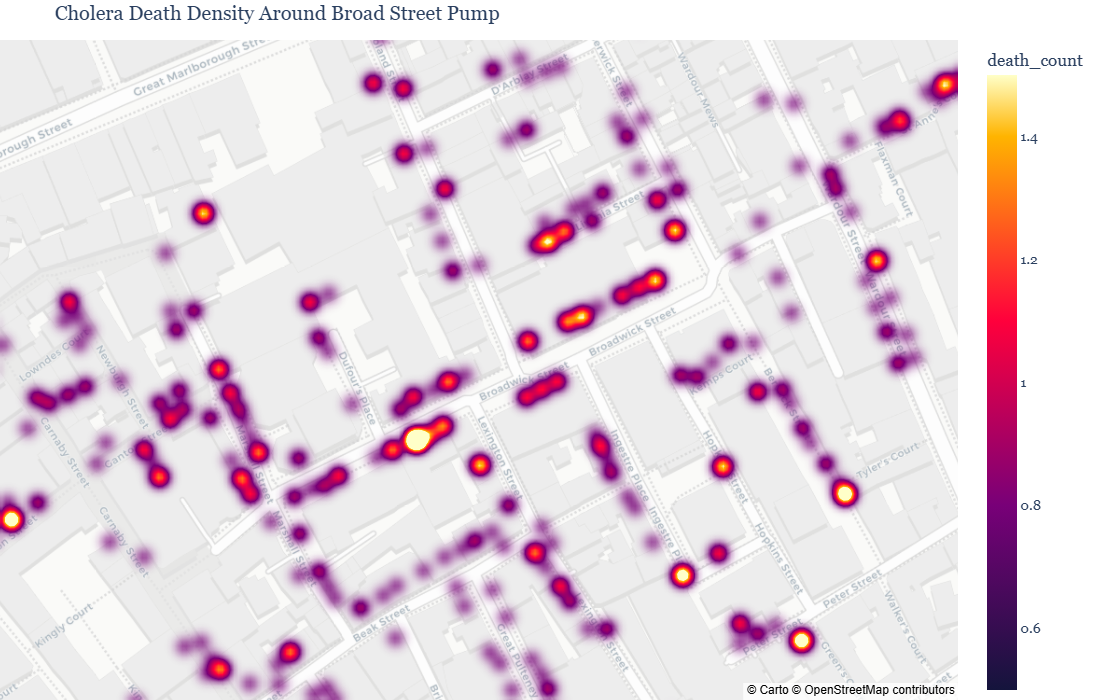

In [29]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

death_count = pd.read_csv(r"C:\Users\Sai Lalit\Downloads\death_count_list.csv")
pumps = pd.read_csv(r"C:\Users\Sai Lalit\Downloads\pump_names_list.csv")
dates = pd.read_csv(r"C:\Users\Sai Lalit\Downloads\snow_dates.csv")


fig = px.density_mapbox(
    death_count,
    lat="latitude",
    lon="longitude",
    z="death_count",
    radius=20,
    center=dict(lat=51.5135, lon=-0.1365),
    zoom=16.9,
    mapbox_style="carto-positron",
    color_continuous_scale=[
        [0.0, "rgb(20,20,60)"],
        [0.3, "rgb(120,0,120)"],
        [0.6, "rgb(255,0,60)"],
        [0.9, "rgb(255,180,0)"],
        [1.0, "rgb(255,255,200)"]
    ],
    title="Cholera Death Density Around Broad Street Pump"
)

# Layout improvements
fig.update_layout(
    font= dict(family='Georgia', size=14),
    height=700,
    margin={"r":0,"t":40,"l":0,"b":0}
)

fig.show()


**The animated version of the outbreak also shows the death over time with the date and month as already mentioned. Well, that is the carto dark matter map style. That is the best way to represent the heatmap animation. Also, each frame is representative of a date, and it also shows how the fatalities are spreading over SOHO.**


C:\Users\Sai Lalit\AppData\Local\Temp\ipykernel_8932\3784352644.py:16: DeprecationWarning:

*density_mapbox* is deprecated! Use *density_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



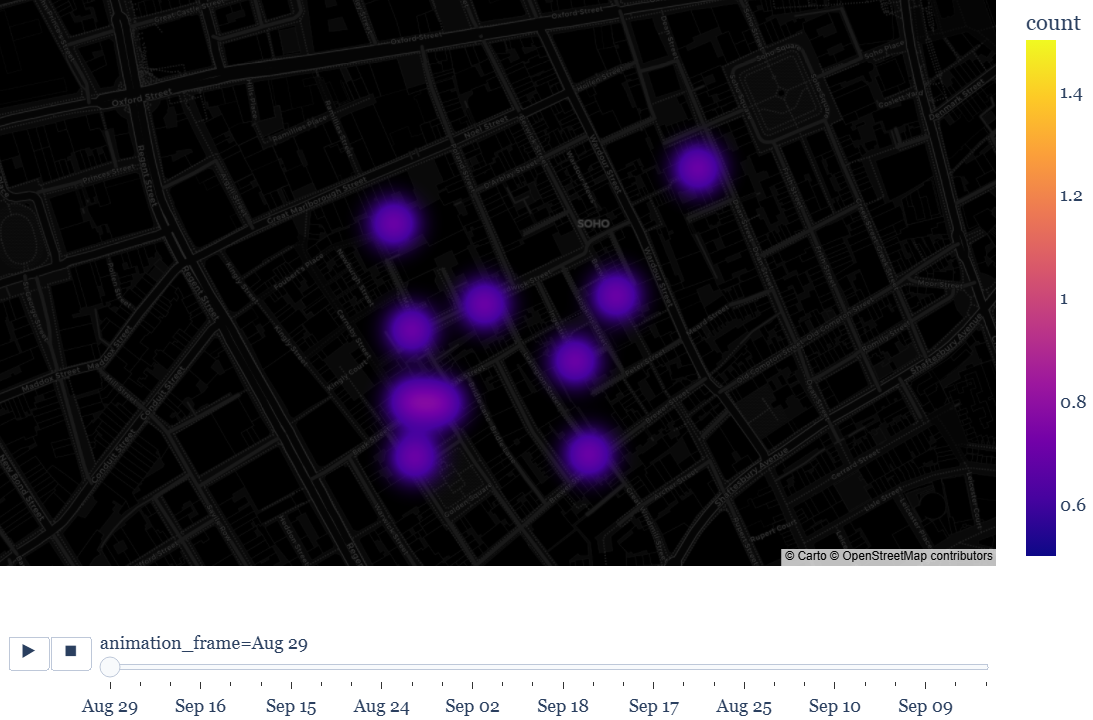

In [43]:
import pandas as pd
import numpy as np
import plotly.express as px

# Load data
deaths = pd.read_csv(r"C:\Users\Sai Lalit\Downloads\death_count_list.csv")

# Simulate death dates for animation 
np.random.seed(42) 
deaths['date'] = pd.to_datetime('1854-08-20') + pd.to_timedelta(np.random.randint(0, 30, size=len(deaths)), unit='D')

# Group by location and date
death_map = deaths.groupby(['latitude', 'longitude', 'date']).size().reset_index(name='count')

# Created animated heatmap
fig = px.density_mapbox(
    death_map,
    lat='latitude',
    lon='longitude',
    z='count',
    radius=50, 
    animation_frame=death_map['date'].dt.strftime('%b %d'),
    center=dict(lat=51.5135, lon=-0.1365), 
    zoom=15.5,  
    mapbox_style='carto-darkmatter',
)

#layout
fig.update_layout(
    font=dict(family='Georgia', size=18),
    margin=dict(t=0, l=0, r=0, b=0),
    height=720# 
)

fig.show()


**Finally, here the bar chart represents the cumulative number of deaths from cholera over time. This enables us to understand the progression of the disease over different periods of time. The map visualization shows the geographic locations of deaths from the cholera outbreak in the Soho area. This map represents the locations of the deaths using markers of different sizes and colors, representing the number of deaths at a particular location. There are also the locations of the water pumps, represented by blue-colored markers, as they were the source of drinking water at the time. From the map, it is evident that the locations of the deaths caused by the disease are concentrated around the locations of the pumps.**

C:\Users\Sai Lalit\AppData\Local\Temp\ipykernel_8932\557480872.py:31: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

C:\Users\Sai Lalit\AppData\Local\Temp\ipykernel_8932\557480872.py:47: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



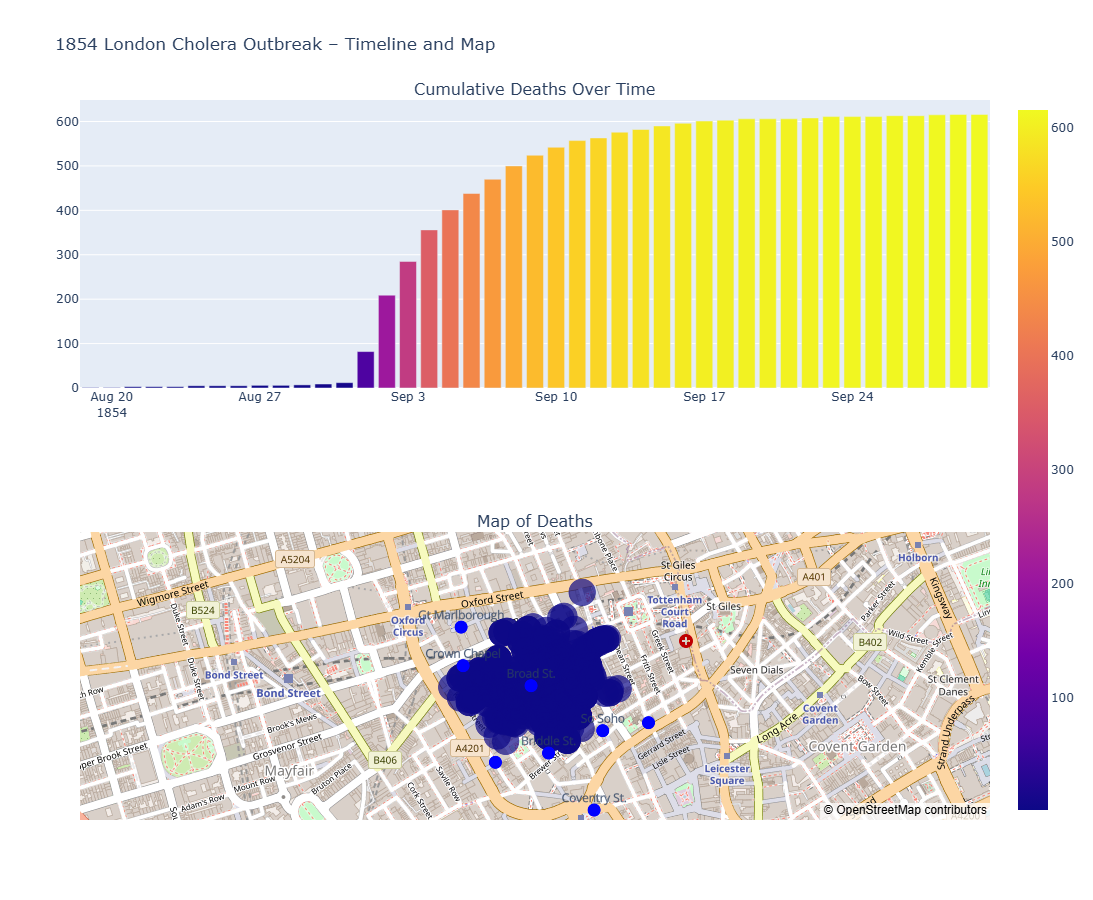

In [31]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Load data
dates = pd.read_csv(r"C:\Users\Sai Lalit\Downloads\snow_dates.csv")
map_data = pd.read_csv(r"C:\Users\Sai Lalit\Downloads\death_count_list.csv")

# Converted date column to datetime
dates["date"] = pd.to_datetime(dates["date"])
dates["cumulative_deaths"] = dates["deaths"].cumsum()

# Creating Bar Chart
bar_fig = px.bar(
    dates,
    x="date",
    y="cumulative_deaths",
    color="cumulative_deaths",
    hover_data={"date": True, "cumulative_deaths": True},
    color_continuous_scale="Reds",
    title="Cumulative Cholera Deaths – 1854 London Outbreak"
)
bar_fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Cumulative Deaths",
    height=400
)

#  Creating Map for Death Locations
map_fig = px.scatter_mapbox(
    map_data,
    lat="latitude",
    lon="longitude",
    size="death_count",          # corrected column name
    color="death_count",         # corrected column name
    hover_name="death_count",
    hover_data={"latitude": True, "longitude": True},
    zoom=14,
    height=500,
    color_continuous_scale="Reds",
    title="Cholera Deaths – 1854 London."
)

# Adding pump locations if available
map_fig.add_trace(
    go.Scattermapbox(
        lat=pumps["latitude"],
        lon=pumps["longitude"],
        mode="markers+text",
        marker=go.scattermapbox.Marker(
            size=14,
            color="blue"
        ),
        text=pumps["pump_name"],
        textposition="top center",
        name="Water Pumps."
    )
)
map_fig.update_layout(
    mapbox_style="open-street-map",
    margin={"r":0,"t":40,"l":0,"b":0}
)

# Combining Charts
fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=("Cumulative Deaths Over Time", "Map of Deaths"),
    vertical_spacing=0.2,
    specs=[[{"type": "xy"}],
           [{"type": "mapbox"}]]
)

# Added bar chart traces
for trace in bar_fig.data:
    fig.add_trace(trace, row=1, col=1)

# Added map traces
for trace in map_fig.data:
    fig.add_trace(trace, row=2, col=1)

# Layout adjustments
fig.update_layout(
    height=900,
    mapbox=dict(
        style="open-street-map",
        center={"lat":51.5136, "lon":-0.1365},  # Soho, London
        zoom=14
    ),
    showlegend=False,
    title_text="1854 London Cholera Outbreak – Timeline and Map"
)

fig.show()